# 1. Experiment 3

In [1]:
from getpass import getpass
HF_TOKEN = getpass("HF token: ")

HF token: ··········


## 2. Install and configuration

In [2]:
!pip install -q -U \
    "transformers>=4.52,<5" \
    "accelerate>=1.5,<2" \
    "huggingface_hub>=0.30,<2" \
    "qwen-vl-utils>=0.0.10,<1" \
    "scikit-learn>=1.4,<2" \
    "scipy>=1.12,<2" \
    "statsmodels>=0.14,<1" \
    "openpyxl>=3.1,<4" \
    "matplotlib>=3.8,<4"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 6.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 110.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 46.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 123.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 138.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.5/35.5 MB 21.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.20.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatibl

In [3]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [4]:
import gc, hashlib, itertools, json, math, random, re, sys, warnings
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
from scipy import stats
from sklearn.neighbors import NearestNeighbors
from statsmodels.stats.multitest import multipletests
import statsmodels.api as sm

from transformers import (
    AutoProcessor,
    PaliGemmaForConditionalGeneration,
    Qwen2_5_VLForConditionalGeneration,
)

SEED = 20260730
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

RUN_NAME = "experiment3_5images"
ROOT = Path("/content/drive/MyDrive/ESSR") / RUN_NAME
DATA_DIR = ROOT / "synthetic_dataset"
IMAGES_DIR = DATA_DIR / "images"
LABELS_DIR = DATA_DIR / "label_maps"
MANIFEST_PATH = DATA_DIR / "manifest.jsonl"
PROMPTS_DIR = ROOT / "prompts"
VECTORS_DIR = ROOT / "vectors"
RESULTS_DIR = ROOT / "results"
FIGURES_DIR = RESULTS_DIR / "figures"

for p in [DATA_DIR, IMAGES_DIR, LABELS_DIR, PROMPTS_DIR, VECTORS_DIR, RESULTS_DIR, FIGURES_DIR]:
    p.mkdir(parents=True, exist_ok=True)

PRIMARY_MODEL_ID = "google/paligemma2-3b-pt-448"
SECONDARY_MODEL_ID = "Qwen/Qwen2.5-VL-3B-Instruct"

CANVAS_SIZE = 384
OBJECT_COUNTS = list(range(2, 33))
N_IMAGES_PER_COUNT = 5
QWEN_COUNTS = [2, 4, 8, 16, 32]
QWEN_IMAGES_PER_COUNT = 5
CONDITIONS = ["c2", "c3", "c4", "c5", "c6"]
PRIMARY_ID_K = 10
ID_K_VALUES = [5, 10, 15]

RUN_PALIGEMMA = True
RUN_QWEN = True
RUN_QWEN_IMAGE_FIRST_NULL = True
RESUME_CURRENT_RUN = True
REQUIRE_BFLOAT16 = False
ATTN_IMPLEMENTATION = "eager"

PROCRUSTES_NULL_COUNTS = [2, 4, 8, 16, 32]
PROCRUSTES_NULL_IMAGES_PER_COUNT = 5
PROCRUSTES_NULL_PERMUTATIONS = 50

print("Fresh run root:", ROOT)

Fresh run root: /content/drive/MyDrive/ESSR/experiment3_5images


In [5]:

# ===== Experiment 3 checkpoint utilities =====
# Saves progress to Google Drive so Colab disconnects do not destroy progress.

PROGRESS_FILE = ROOT / "experiment3_progress.json"

def save_progress(stage, completed, total):
    progress = {
        "stage": stage,
        "completed": int(completed),
        "total": int(total),
    }
    with open(PROGRESS_FILE, "w") as f:
        json.dump(progress, f, indent=2)

def load_progress():
    if PROGRESS_FILE.exists():
        with open(PROGRESS_FILE) as f:
            return json.load(f)
    return {}

print("Checkpoint system ready:", PROGRESS_FILE)


Checkpoint system ready: /content/drive/MyDrive/ESSR/experiment3_5images/experiment3_progress.json


In [6]:
run_config = {
    "seed": SEED,
    "canvas_size": CANVAS_SIZE,
    "object_counts": OBJECT_COUNTS,
    "n_images_per_count": N_IMAGES_PER_COUNT,
    "qwen_counts": QWEN_COUNTS,
    "qwen_images_per_count": QWEN_IMAGES_PER_COUNT,
    "primary_model": PRIMARY_MODEL_ID,
    "secondary_model": SECONDARY_MODEL_ID,
    "conditions": CONDITIONS,
    "primary_id_k": PRIMARY_ID_K,
    "id_k_values": ID_K_VALUES,
    "attention_implementation": ATTN_IMPLEMENTATION,
}

config_path = ROOT / "run_config.json"
if config_path.exists():
    saved = json.loads(config_path.read_text(encoding="utf-8"))
    if saved != run_config:
        raise RuntimeError("Existing fresh-run folder has a different configuration. Change RUN_NAME.")
else:
    config_path.write_text(json.dumps(run_config, indent=2), encoding="utf-8")

## 3. Generate new synthetic scenes with exact object labels

In [7]:
COLOR_PALETTE = {
    "red": (220, 50, 47), "blue": (38, 111, 209), "green": (42, 161, 74),
    "yellow": (238, 190, 46), "purple": (130, 78, 185), "orange": (235, 112, 37),
    "cyan": (39, 174, 196), "pink": (224, 90, 151), "brown": (145, 92, 55),
    "teal": (34, 139, 131), "lime": (133, 187, 51), "navy": (44, 62, 120),
}
SHAPES = ["circle", "square", "triangle"]
DESCRIPTORS = [(c, s) for c in COLOR_PALETTE for s in SHAPES]
assert len(DESCRIPTORS) == 36

GRID_SIDE = 6
GRID_MARGIN = 34
GRID_STEP = (CANVAS_SIZE - 2 * GRID_MARGIN) / (GRID_SIDE - 1)
GRID_CENTERS = [
    (int(round(GRID_MARGIN + col * GRID_STEP)), int(round(GRID_MARGIN + row * GRID_STEP)))
    for row in range(GRID_SIDE) for col in range(GRID_SIDE)
]

def draw_shape(draw_rgb, draw_labels, object_id, shape, color, center, radius):
    cx, cy = center
    bbox = [cx-radius, cy-radius, cx+radius, cy+radius]
    if shape == "circle":
        draw_rgb.ellipse(bbox, fill=color); draw_labels.ellipse(bbox, fill=object_id)
    elif shape == "square":
        draw_rgb.rectangle(bbox, fill=color); draw_labels.rectangle(bbox, fill=object_id)
    elif shape == "triangle":
        points = [(cx, cy-radius), (cx-radius, cy+radius), (cx+radius, cy+radius)]
        draw_rgb.polygon(points, fill=color); draw_labels.polygon(points, fill=object_id)
    else:
        raise ValueError(shape)
    return [int(v) for v in bbox]

def generate_scene(object_count, image_index):
    scene_seed = SEED + object_count * 100_000 + image_index
    rng = random.Random(scene_seed)
    positions = rng.sample(GRID_CENTERS, object_count)
    descriptors = rng.sample(DESCRIPTORS, object_count)

    image = Image.new("RGB", (CANVAS_SIZE, CANVAS_SIZE), (242, 242, 242))
    labels = Image.new("L", (CANVAS_SIZE, CANVAS_SIZE), 0)
    draw_rgb, draw_labels = ImageDraw.Draw(image), ImageDraw.Draw(labels)

    objects = []
    for object_id, ((color_name, shape), center) in enumerate(zip(descriptors, positions), start=1):
        radius = rng.randint(18, 24)
        bbox = draw_shape(
            draw_rgb, draw_labels, object_id, shape,
            COLOR_PALETTE[color_name], center, radius,
        )
        objects.append({
            "object_id": object_id,
            "color": color_name,
            "shape": shape,
            "name": f"{color_name} {shape}",
            "bbox": bbox,
            "centroid": [center[0] / CANVAS_SIZE, center[1] / CANVAS_SIZE],
        })

    image_id = f"n{object_count:02d}_i{image_index:03d}"
    return image_id, image, labels, objects, scene_seed

In [8]:
expected_images = len(OBJECT_COUNTS) * N_IMAGES_PER_COUNT

if MANIFEST_PATH.exists() and RESUME_CURRENT_RUN:
    manifest = [
        json.loads(line)
        for line in MANIFEST_PATH.read_text(encoding="utf-8").splitlines()
        if line.strip()
    ]
    assert len(manifest) == expected_images
else:
    manifest = []
    for object_count in OBJECT_COUNTS:
        for image_index in range(N_IMAGES_PER_COUNT):
            image_id, image, labels, objects, scene_seed = generate_scene(object_count, image_index)
            image_filename = f"{image_id}.png"
            label_filename = f"{image_id}_labels.png"
            image.save(IMAGES_DIR / image_filename)
            labels.save(LABELS_DIR / label_filename)
            manifest.append({
                "image_id": image_id,
                "object_count": object_count,
                "image_index": image_index,
                "scene_seed": scene_seed,
                "image_filename": image_filename,
                "label_filename": label_filename,
                "objects": objects,
            })

    with MANIFEST_PATH.open("w", encoding="utf-8") as f:
        for record in manifest:
            f.write(json.dumps(record) + "\n")

assert len(manifest) == expected_images
print("Synthetic images:", len(manifest))

Synthetic images: 155


In [9]:
integrity_rows = []
for record in manifest:
    image = Image.open(IMAGES_DIR / record["image_filename"])
    labels = np.asarray(Image.open(LABELS_DIR / record["label_filename"]), dtype=np.uint8)
    ids = sorted(int(x) for x in np.unique(labels) if x != 0)
    assert image.size == (CANVAS_SIZE, CANVAS_SIZE)
    assert ids == list(range(1, record["object_count"] + 1))
    assert len({o["name"] for o in record["objects"]}) == record["object_count"]
    integrity_rows.append({
        "image_id": record["image_id"],
        "object_count": record["object_count"],
        "min_object_pixels": min(int((labels == i).sum()) for i in ids),
    })

dataset_integrity = pd.DataFrame(integrity_rows)
display(dataset_integrity.groupby("object_count").agg(
    images=("image_id", "count"),
    min_object_pixels=("min_object_pixels", "min"),
))

,images,min_object_pixels
object_count,,
2,5,761
3,5,685
4,5,685
5,5,685
6,5,685
7,5,685
8,5,685
9,5,685
10,5,685


## 4. Prompt generation with exact tokenizer matching

In [10]:
NEUTRAL_LONG_SUFFIX = (
    "\nAdditional neutral context: the notes were reviewed carefully, "
    "the schedule remained unchanged, and no further action was taken "
    "during the routine discussion."
)

IRRELEVANT_SUBJECTS = [
    "winter concert", "morning lecture", "weekly meeting", "spring workshop",
    "evening rehearsal", "monthly report", "library seminar", "travel briefing",
    "finance review", "history lesson", "music session", "science discussion",
    "committee update", "training session", "reading group", "policy meeting",
]
IRRELEVANT_RELATIONS = ["before", "after", "near", "beside", "earlier than", "later than"]
IRRELEVANT_TAILS = [
    "", " today", " this week", " during the afternoon",
    " before the break", " after the discussion", " without delay", " as planned",
]

IRRELEVANT_CANDIDATES = sorted({
    f"The {a} is {relation} the {b}{tail}."
    for a, b, relation, tail in itertools.product(
        IRRELEVANT_SUBJECTS, IRRELEVANT_SUBJECTS,
        IRRELEVANT_RELATIONS, IRRELEVANT_TAILS,
    )
    if a != b
} | {
    f"Today, the {a} is {relation} the {b}{tail}."
    for a, b, relation, tail in itertools.product(
        IRRELEVANT_SUBJECTS, IRRELEVANT_SUBJECTS,
        IRRELEVANT_RELATIONS, IRRELEVANT_TAILS,
    )
    if a != b
})

def select_relevant_prompt(record):
    best = None
    for i, first in enumerate(record["objects"]):
        for j, second in enumerate(record["objects"]):
            if i == j:
                continue
            x1, y1 = first["centroid"]; x2, y2 = second["centroid"]
            dx, dy = x1-x2, y1-y2
            if abs(dx) >= abs(dy):
                relation, strength = ("left of" if dx < 0 else "right of"), abs(dx)
            else:
                relation, strength = ("above" if dy < 0 else "below"), abs(dy)
            candidate = (strength, first, relation, second)
            if best is None or candidate[0] > best[0]:
                best = candidate
    _, first, relation, second = best
    return f"The {first['name']} is {relation} the {second['name']}."

def token_count(tokenizer, text):
    return len(tokenizer(text, add_special_tokens=False)["input_ids"])

def build_prompts(record, tokenizer, model_key):
    c5 = select_relevant_prompt(record)
    c6 = c5 + NEUTRAL_LONG_SUFFIX
    short_target = token_count(tokenizer, c5)
    long_target = token_count(tokenizer, c6)

    valid = [
        c for c in IRRELEVANT_CANDIDATES
        if token_count(tokenizer, c) == short_target
        and token_count(tokenizer, c + NEUTRAL_LONG_SUFFIX) == long_target
    ]
    if not valid:
        raise RuntimeError(
            f"No exact irrelevant match for {record['image_id']} under {model_key}: "
            f"targets {short_target}/{long_target}."
        )

    h = int(hashlib.sha256(f"{SEED}|{model_key}|{record['image_id']}".encode()).hexdigest()[:8], 16)
    c4 = valid[h % len(valid)]
    c3 = c4 + NEUTRAL_LONG_SUFFIX

    prompts = {"c2": "", "c3": c3, "c4": c4, "c5": c5, "c6": c6}
    assert token_count(tokenizer, c4) == token_count(tokenizer, c5)
    assert token_count(tokenizer, c3) == token_count(tokenizer, c6)
    return prompts

In [11]:
def save_prompt_table(model_key, records, tokenizer):
    path = PROMPTS_DIR / f"{model_key}_prompts.jsonl"
    if path.exists() and RESUME_CURRENT_RUN:
        rows = [json.loads(x) for x in path.read_text(encoding="utf-8").splitlines() if x.strip()]
        assert len(rows) == len(records)
        return rows

    rows = []
    for record in records:
        prompts = build_prompts(record, tokenizer, model_key)
        rows.append({
            "image_id": record["image_id"],
            "object_count": record["object_count"],
            "prompts": prompts,
            "token_counts": {c: token_count(tokenizer, t) for c, t in prompts.items()},
        })

    with path.open("w", encoding="utf-8") as f:
        for row in rows:
            f.write(json.dumps(row) + "\n")
    return rows

## 5. Shared mask-to-token pooling

In [12]:
def patch_weights_from_label_map(label_map, object_count, grid_height, grid_width):
    labels = np.asarray(label_map, dtype=np.int64)

    # Отдельная точная бинарная маска для каждого объекта
    masks = np.stack(
        [
            (labels == object_id).astype(np.float32)
            for object_id in range(1, object_count + 1)
        ],
        axis=0,
    )

    masks = torch.from_numpy(masks).unsqueeze(1)

    # Area pooling сохраняет даже маленькие объекты,
    # которые исчезали при NEAREST resizing
    weights = torch.nn.functional.interpolate(
        masks,
        size=(grid_height, grid_width),
        mode="area",
    ).squeeze(1)

    weights = weights.reshape(object_count, -1)

    # Дополнительная защита: назначаем исчезнувший объект
    # ближайшему токену по его центру
    for object_index in range(object_count):
        if weights[object_index].sum() <= 0:
            ys, xs = np.where(labels == object_index + 1)

            if len(xs) == 0:
                raise RuntimeError(
                    f"Object {object_index + 1} is absent from the original label map."
                )

            center_y = float(ys.mean())
            center_x = float(xs.mean())

            grid_y = min(
                grid_height - 1,
                int(center_y * grid_height / labels.shape[0]),
            )
            grid_x = min(
                grid_width - 1,
                int(center_x * grid_width / labels.shape[1]),
            )

            weights[object_index, grid_y * grid_width + grid_x] = 1.0

    return weights

def pool_object_vectors(token_states, object_weights, eps=1e-8):
    weights = object_weights.float()
    states = token_states.float()
    return (weights @ states) / weights.sum(dim=1, keepdim=True).clamp_min(eps)

## 6. Model adapters and full inference

In [13]:
def get_hf_token():
    # Keep token entered manually in Colab if available
    if "HF_TOKEN" in globals() and HF_TOKEN:
        return HF_TOKEN
    try:
        from google.colab import userdata
        return userdata.get("HF_TOKEN")
    except Exception:
        return None

HF_TOKEN = get_hf_token()


if REQUIRE_BFLOAT16:
    if not torch.cuda.is_available():
        raise RuntimeError("A GPU runtime is required.")
    if not torch.cuda.is_bf16_supported():
        raise RuntimeError("Use an A100/H100-class GPU with bfloat16 support.")

MODEL_DTYPE = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16
torch.backends.cuda.matmul.allow_tf32 = False
torch.backends.cudnn.allow_tf32 = False

@dataclass
class ExtractedCondition:
    vectors: np.ndarray
    total_sequence_length: int
    image_token_count: int
    grid_height: int
    grid_width: int

def final_quarter_outputs(num_outputs):
    return list(range(max(1, math.ceil(num_outputs * 0.75)), num_outputs))

### 6.1 PaliGemma 2

In [14]:
def load_paligemma():
    processor = AutoProcessor.from_pretrained(PRIMARY_MODEL_ID, token=HF_TOKEN)
    model = PaliGemmaForConditionalGeneration.from_pretrained(
        PRIMARY_MODEL_ID,
        token=HF_TOKEN,
        torch_dtype=MODEL_DTYPE,
        device_map="auto",
        low_cpu_mem_usage=True,
        attn_implementation=ATTN_IMPLEMENTATION,
    ).eval()
    return processor, model

def extract_paligemma_condition(processor, model, image, label_map, object_count, prompt):
    inputs = processor(images=image, text=prompt, return_tensors="pt")
    device = next(model.parameters()).device
    prepared = {
        key: (
            value.to(device=device, dtype=MODEL_DTYPE)
            if key == "pixel_values"
            else value.to(device)
        )
        for key, value in inputs.items()
    }

    image_token_id = int(model.config.image_token_index)
    image_positions = prepared["input_ids"][0] == image_token_id
    image_token_count = int(image_positions.sum().item())
    grid_side = int(round(math.sqrt(image_token_count)))
    assert grid_side * grid_side == image_token_count

    with torch.inference_mode():
        outputs = model(
            **prepared,
            output_hidden_states=True,
            return_dict=True,
            use_cache=False,
        )

    image_states = torch.stack([
        hidden[0, image_positions, :].float().cpu()
        for hidden in outputs.hidden_states
    ])
    weights = patch_weights_from_label_map(
        label_map, object_count, grid_side, grid_side
    )
    pooled = torch.stack([
        pool_object_vectors(state, weights)
        for state in image_states
    ])

    return ExtractedCondition(
        vectors=pooled.numpy().astype(np.float32),
        total_sequence_length=int(prepared["input_ids"].shape[1]),
        image_token_count=image_token_count,
        grid_height=grid_side,
        grid_width=grid_side,
    )

In [15]:
PALIGEMMA_VECTOR_DIR = VECTORS_DIR / "paligemma_full"
PALIGEMMA_VECTOR_DIR.mkdir(parents=True, exist_ok=True)

if RUN_PALIGEMMA:
    pali_processor, pali_model = load_paligemma()
    pali_prompt_rows = save_prompt_table(
        "paligemma", manifest, pali_processor.tokenizer
    )
    pali_prompt_map = {row["image_id"]: row for row in pali_prompt_rows}

    for run_index, record in enumerate(manifest, start=1):
        output_path = PALIGEMMA_VECTOR_DIR / f"{record['image_id']}.npz"

        if output_path.exists() and RESUME_CURRENT_RUN:
            print(f"[{run_index:03d}/{len(manifest)}] skip {record['image_id']}")
            continue

        image = Image.open(IMAGES_DIR / record["image_filename"]).convert("RGB")
        label_map = Image.open(LABELS_DIR / record["label_filename"])
        prompts = pali_prompt_map[record["image_id"]]["prompts"]

        extracted = {
            condition: extract_paligemma_condition(
                pali_processor, pali_model, image, label_map,
                record["object_count"], prompts[condition],
            )
            for condition in CONDITIONS
        }

        assert extracted["c4"].total_sequence_length == extracted["c5"].total_sequence_length
        assert extracted["c3"].total_sequence_length == extracted["c6"].total_sequence_length
        assert len({
            (x.image_token_count, x.grid_height, x.grid_width)
            for x in extracted.values()
        }) == 1

        np.savez_compressed(
            output_path,
            image_id=np.asarray(record["image_id"]),
            object_count=np.asarray(record["object_count"]),
            object_names=np.asarray([o["name"] for o in record["objects"]], dtype=str),
            **{f"{c}_vectors": extracted[c].vectors for c in CONDITIONS},
            **{
                f"{c}_sequence_length": np.asarray(extracted[c].total_sequence_length)
                for c in CONDITIONS
            },
            image_token_count=np.asarray(extracted["c2"].image_token_count),
            grid_height=np.asarray(extracted["c2"].grid_height),
            grid_width=np.asarray(extracted["c2"].grid_width),
        )

        print(f"[{run_index:03d}/{len(manifest)}] saved {record['image_id']}")
        gc.collect()
        torch.cuda.empty_cache()

    del pali_model, pali_processor
    gc.collect()
    torch.cuda.empty_cache()

preprocessor_config.json:   0%|          | 0.00/425 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/34.6M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/733 [00:00<?, ?B/s]

...

[153/155] saved n32_i002


You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.
You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.
You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.
Y

[154/155] saved n32_i003


You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.
You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.
You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.
Y

[155/155] saved n32_i004


### 6.2 Qwen2.5-VL reduced generalization

In [16]:
def load_qwen():
    processor = AutoProcessor.from_pretrained(SECONDARY_MODEL_ID, token=HF_TOKEN)
    model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
        SECONDARY_MODEL_ID,
        token=HF_TOKEN,
        torch_dtype=MODEL_DTYPE,
        device_map="auto",
        low_cpu_mem_usage=True,
        attn_implementation=ATTN_IMPLEMENTATION,
    ).eval()
    return processor, model

def build_qwen_inputs(processor, image, prompt, text_before_image=True):
    content = []
    if text_before_image and prompt:
        content.append({"type": "text", "text": prompt})
    content.append({"type": "image", "image": image})
    if (not text_before_image) and prompt:
        content.append({"type": "text", "text": prompt})

    text = processor.apply_chat_template(
        [{"role": "user", "content": content}],
        tokenize=False,
        add_generation_prompt=False,
    )
    return processor(
        text=[text],
        images=[image],
        padding=True,
        return_tensors="pt",
    )

def extract_qwen_condition(
    processor, model, image, label_map, object_count, prompt,
    text_before_image=True,
):
    inputs = build_qwen_inputs(
        processor, image, prompt, text_before_image=text_before_image
    )
    device = next(model.parameters()).device
    prepared = {
        key: (
            value.to(device=device, dtype=MODEL_DTYPE)
            if key == "pixel_values"
            else value.to(device)
        )
        for key, value in inputs.items()
    }

    image_token_id = int(model.config.image_token_id)
    image_positions = prepared["input_ids"][0] == image_token_id
    image_token_count = int(image_positions.sum().item())

    grid_t, grid_h, grid_w = [
        int(x) for x in prepared["image_grid_thw"][0].tolist()
    ]
    merge_size = int(processor.image_processor.merge_size)
    effective_h = grid_h // merge_size
    effective_w = grid_w // merge_size
    assert image_token_count == grid_t * effective_h * effective_w

    with torch.inference_mode():
        outputs = model(
            **prepared,
            output_hidden_states=True,
            return_dict=True,
            use_cache=False,
        )

    image_states = torch.stack([
        hidden[0, image_positions, :].float().cpu()
        for hidden in outputs.hidden_states
    ])
    weights = patch_weights_from_label_map(
        label_map, object_count, effective_h, effective_w
    )
    pooled = torch.stack([
        pool_object_vectors(state, weights)
        for state in image_states
    ])

    return ExtractedCondition(
        vectors=pooled.numpy().astype(np.float32),
        total_sequence_length=int(prepared["input_ids"].shape[1]),
        image_token_count=image_token_count,
        grid_height=effective_h,
        grid_width=effective_w,
    )

In [17]:
QWEN_VECTOR_DIR = VECTORS_DIR / "qwen_reduced_text_first"
QWEN_NULL_DIR = VECTORS_DIR / "qwen_image_first_null"
QWEN_VECTOR_DIR.mkdir(parents=True, exist_ok=True)
QWEN_NULL_DIR.mkdir(parents=True, exist_ok=True)

qwen_records = [
    record for record in manifest
    if record["object_count"] in QWEN_COUNTS
    and record["image_index"] < QWEN_IMAGES_PER_COUNT
]
assert len(qwen_records) == len(QWEN_COUNTS) * QWEN_IMAGES_PER_COUNT

if RUN_QWEN:
    qwen_processor, qwen_model = load_qwen()
    qwen_prompt_rows = save_prompt_table(
        "qwen", qwen_records, qwen_processor.tokenizer
    )
    qwen_prompt_map = {row["image_id"]: row for row in qwen_prompt_rows}

    for run_index, record in enumerate(qwen_records, start=1):
        output_path = QWEN_VECTOR_DIR / f"{record['image_id']}.npz"

        if output_path.exists() and RESUME_CURRENT_RUN:
            print(f"[{run_index:03d}/{len(qwen_records)}] skip {record['image_id']}")
            continue

        image = Image.open(IMAGES_DIR / record["image_filename"]).convert("RGB")
        label_map = Image.open(LABELS_DIR / record["label_filename"])
        prompts = qwen_prompt_map[record["image_id"]]["prompts"]

        extracted = {
            condition: extract_qwen_condition(
                qwen_processor, qwen_model, image, label_map,
                record["object_count"], prompts[condition],
                text_before_image=True,
            )
            for condition in CONDITIONS
        }

        assert extracted["c4"].total_sequence_length == extracted["c5"].total_sequence_length
        assert extracted["c3"].total_sequence_length == extracted["c6"].total_sequence_length

        np.savez_compressed(
            output_path,
            image_id=np.asarray(record["image_id"]),
            object_count=np.asarray(record["object_count"]),
            object_names=np.asarray([o["name"] for o in record["objects"]], dtype=str),
            **{f"{c}_vectors": extracted[c].vectors for c in CONDITIONS},
            **{
                f"{c}_sequence_length": np.asarray(extracted[c].total_sequence_length)
                for c in CONDITIONS
            },
            image_token_count=np.asarray(extracted["c2"].image_token_count),
            grid_height=np.asarray(extracted["c2"].grid_height),
            grid_width=np.asarray(extracted["c2"].grid_width),
        )

        print(f"[{run_index:03d}/{len(qwen_records)}] saved {record['image_id']}")
        gc.collect()
        torch.cuda.empty_cache()

preprocessor_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. Note that this behavior will be extended to all models in a future release.


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

model-00002-of-00002.safetensors:   0%|          | 0.00/3.53G [00:00<?, ?B/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/3.98G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/216 [00:00<?, ?B/s]

[001/25] saved n02_i000
[002/25] saved n02_i001
[003/25] saved n02_i002
[004/25] saved n02_i003
[005/25] saved n02_i004
[006/25] saved n04_i000
[007/25] saved n04_i001
[008/25] saved n04_i002
[009/25] saved n04_i003
[010/25] saved n04_i004
[011/25] saved n08_i000
[012/25] saved n08_i001
[013/25] saved n08_i002
[014/25] saved n08_i003
[015/25] saved n08_i004
[016/25] saved n16_i000
[017/25] saved n16_i001
[018/25] saved n16_i002
[019/25] saved n16_i003
[020/25] saved n16_i004
[021/25] saved n32_i000
[022/25] saved n32_i001
[023/25] saved n32_i002
[024/25] saved n32_i003
[025/25] saved n32_i004


In [18]:
if RUN_QWEN and RUN_QWEN_IMAGE_FIRST_NULL:
    null_records = [
        record for record in qwen_records
        if record["object_count"] in [2, 8, 32]
        and record["image_index"] < 3
    ]

    for run_index, record in enumerate(null_records, start=1):
        output_path = QWEN_NULL_DIR / f"{record['image_id']}.npz"
        if output_path.exists() and RESUME_CURRENT_RUN:
            continue

        image = Image.open(IMAGES_DIR / record["image_filename"]).convert("RGB")
        label_map = Image.open(LABELS_DIR / record["label_filename"])
        prompts = qwen_prompt_map[record["image_id"]]["prompts"]

        extracted = {
            condition: extract_qwen_condition(
                qwen_processor, qwen_model, image, label_map,
                record["object_count"], prompts[condition],
                text_before_image=False,
            )
            for condition in CONDITIONS
        }

        np.savez_compressed(
            output_path,
            image_id=np.asarray(record["image_id"]),
            object_count=np.asarray(record["object_count"]),
            **{f"{c}_vectors": extracted[c].vectors for c in CONDITIONS},
        )
        print(f"[null {run_index}/{len(null_records)}] {record['image_id']}")

if RUN_QWEN:
    del qwen_model, qwen_processor
    gc.collect()
    torch.cuda.empty_cache()

[null 1/9] n02_i000
[null 2/9] n02_i001
[null 3/9] n02_i002
[null 4/9] n08_i000
[null 5/9] n08_i001
[null 6/9] n08_i002
[null 7/9] n32_i000
[null 8/9] n32_i001
[null 9/9] n32_i002


## 7. Load checkpoints from this new run only

In [19]:
def load_vector_checkpoint(path):
    with np.load(path, allow_pickle=True) as data:
        return {
            "image_id": str(np.asarray(data["image_id"]).item()),
            "object_count": int(np.asarray(data["object_count"]).item()),
            "object_names": data["object_names"].astype(str) if "object_names" in data.files else None,
            **{
                condition: data[f"{condition}_vectors"].astype(np.float64)
                for condition in CONDITIONS
            },
        }

def collect_records(records, directory, model_key):
    loaded, missing = [], []
    for record in records:
        path = directory / f"{record['image_id']}.npz"
        if path.exists():
            loaded.append(load_vector_checkpoint(path))
        else:
            missing.append(str(path))
    if missing:
        raise RuntimeError(
            f"{model_key}: {len(missing)} checkpoints missing. Finish inference first."
        )
    return loaded

pali_vectors = collect_records(manifest, PALIGEMMA_VECTOR_DIR, "paligemma")
qwen_vectors = collect_records(qwen_records, QWEN_VECTOR_DIR, "qwen") if RUN_QWEN else []

print("PaliGemma:", len(pali_vectors))
print("Qwen:", len(qwen_vectors))

PaliGemma: 155
Qwen: 25


## 8. Metrics

In [20]:
def normalize_rows(x, eps=1e-12):
    x = np.asarray(x, dtype=np.float64)
    return x / np.maximum(np.linalg.norm(x, axis=1, keepdims=True), eps)

def mean_pairwise_cosine(x):
    x = normalize_rows(x)
    sim = x @ x.T
    upper = np.triu_indices(len(x), k=1)
    return float(sim[upper].mean())

def cosine_rdm_vector(x):
    x = normalize_rows(x)
    rdm = 1.0 - x @ x.T
    upper = np.triu_indices(len(x), k=1)
    return rdm[upper]

def delta_rdm(condition, baseline):
    delta = cosine_rdm_vector(condition) - cosine_rdm_vector(baseline)
    return {
        "rmse": float(np.sqrt(np.mean(delta ** 2))),
        "mae": float(np.mean(np.abs(delta))),
        "signed_mean": float(np.mean(delta)),
    }

def prepare_procrustes(x, eps=1e-12):
    x = np.asarray(x, dtype=np.float64)
    x = x - x.mean(axis=0, keepdims=True)
    norm = np.linalg.norm(x, ord="fro")
    if norm < eps:
        raise ValueError("Degenerate configuration.")
    return x / norm

def orthogonal_procrustes_distance(condition, baseline):
    x, y = prepare_procrustes(condition), prepare_procrustes(baseline)
    ux, sx, _ = np.linalg.svd(x, full_matrices=False)
    uy, sy, _ = np.linalg.svd(y, full_matrices=False)
    small_cross = sx[:, None] * (ux.T @ uy) * sy[None, :]
    singular_values = np.linalg.svd(small_cross, compute_uv=False)
    similarity = float(np.clip(singular_values.sum(), 0.0, 1.0))
    return float(np.sqrt(max(0.0, 2.0 - 2.0 * similarity)))

def center_and_normalize_image(x, eps=1e-12):
    x = np.asarray(x, dtype=np.float64)
    x = x - x.mean(axis=0, keepdims=True)
    norms = np.linalg.norm(x, axis=1, keepdims=True)
    if (norms[:, 0] <= eps).any():
        raise ValueError("Zero-norm centered object vector.")
    return x / norms

def mle_intrinsic_dimension(x, k=10, eps=1e-12):
    x = np.asarray(x, dtype=np.float64)
    if len(x) <= k:
        raise ValueError(f"Need more than k={k} points, got {len(x)}.")
    nn = NearestNeighbors(
        n_neighbors=k + 1,
        metric="euclidean",
        algorithm="brute",
        n_jobs=-1,
    ).fit(x)
    distances, _ = nn.kneighbors(x)
    distances = np.maximum(distances[:, 1:], eps)
    t_k = distances[:, -1:]
    inverse_terms = np.log(t_k / distances[:, :-1]).mean(axis=1)
    valid = np.isfinite(inverse_terms) & (inverse_terms > eps)
    return float(1.0 / inverse_terms[valid].mean())

## 9. Recompute geometry from new vectors

In [21]:
def compute_geometry_table(model_key, records):
    rows = []
    for record in records:
        num_outputs = record["c2"].shape[0]
        assert all(record[c].shape == record["c2"].shape for c in CONDITIONS)

        for output_index in range(num_outputs):
            row = {
                "model": model_key,
                "image_id": record["image_id"],
                "object_count": record["object_count"],
                "output_index": output_index,
                "num_outputs": num_outputs,
            }
            for condition in CONDITIONS:
                row[f"{condition}_crowding"] = mean_pairwise_cosine(
                    record[condition][output_index]
                )
            for condition in ["c3", "c4", "c5", "c6"]:
                rdm = delta_rdm(
                    record[condition][output_index],
                    record["c2"][output_index],
                )
                row[f"{condition}_rdm_rmse"] = rdm["rmse"]
                row[f"{condition}_rdm_mae"] = rdm["mae"]
                row[f"{condition}_rdm_signed"] = rdm["signed_mean"]
                row[f"{condition}_procrustes"] = orthogonal_procrustes_distance(
                    record[condition][output_index],
                    record["c2"][output_index],
                )
            rows.append(row)

    result = pd.DataFrame(rows)
    result["is_primary_depth"] = result.apply(
        lambda r: r["output_index"] in final_quarter_outputs(int(r["num_outputs"])),
        axis=1,
    )
    return result

geometry_tables = [compute_geometry_table("paligemma", pali_vectors)]
if qwen_vectors:
    geometry_tables.append(compute_geometry_table("qwen", qwen_vectors))

geometry_results = pd.concat(geometry_tables, ignore_index=True)
geometry_results.to_csv(RESULTS_DIR / "geometry_all_outputs.csv", index=False)
display(geometry_results.groupby("model").agg(
    images=("image_id", "nunique"),
    outputs=("output_index", "nunique"),
))

,images,outputs
model,,
paligemma,155,27
qwen,25,37


## 10. Embedding-output numerical floor

In [22]:
floor_rows = []
for model_key, records in [("paligemma", pali_vectors), ("qwen", qwen_vectors)]:
    for record in records:
        for condition in ["c3", "c4", "c5", "c6"]:
            floor_rows.append({
                "model": model_key,
                "image_id": record["image_id"],
                "object_count": record["object_count"],
                "condition": condition,
                "rdm_rmse": delta_rdm(
                    record[condition][0], record["c2"][0]
                )["rmse"],
                "procrustes": orthogonal_procrustes_distance(
                    record[condition][0], record["c2"][0]
                ),
                "max_abs_vector_difference": float(
                    np.abs(record[condition][0] - record["c2"][0]).max()
                ),
            })

layer0_floor = pd.DataFrame(floor_rows)
layer0_floor.to_csv(RESULTS_DIR / "embedding_output_floor.csv", index=False)
display(layer0_floor.groupby(["model", "condition"]).mean(numeric_only=True))

object_count  rdm_rmse    procrustes  \
model     condition                                         
paligemma c3                 17.0       0.0  1.703999e-08   
          c4                 17.0       0.0  1.703999e-08   
          c5                 17.0       0.0  1.703999e-08   
          c6                 17.0       0.0  1.703999e-08   
qwen      c3                 12.4       0.0  2.177587e-08   
          c4                 12.4       0.0  2.177587e-08   
          c5                 12.4       0.0  2.177587e-08   
          c6                 12.4       0.0  2.177587e-08   

                     max_abs_vector_difference  
model     condition                             
paligemma c3                               0.0  
          c4                               0.0  
          c5                               0.0  
          c6                               0.0  
qwen      c3                               0.0  
          c4                               0.0  
          c5                               0.0  
          c6                               0.0

## 11. Intrinsic dimensionality by object-count cell

In [23]:
def compute_id_table(model_key, records):
    rows = []
    groups = {}
    for record in records:
        groups.setdefault(record["object_count"], []).append(record)

    for object_count, group in sorted(groups.items()):
        num_outputs = group[0]["c2"].shape[0]

        for output_index in range(num_outputs):
            for condition in CONDITIONS:
                pooled = np.vstack([
                    center_and_normalize_image(record[condition][output_index])
                    for record in group
                ])

                for k in ID_K_VALUES:
                    if len(pooled) <= k:
                        continue
                    rows.append({
                        "model": model_key,
                        "object_count": object_count,
                        "output_index": output_index,
                        "num_outputs": num_outputs,
                        "condition": condition,
                        "k": k,
                        "num_images": len(group),
                        "num_vectors": len(pooled),
                        "id_mle": mle_intrinsic_dimension(pooled, k=k),
                    })

    result = pd.DataFrame(rows)
    result["is_primary_depth"] = result.apply(
        lambda r: r["output_index"] in final_quarter_outputs(int(r["num_outputs"])),
        axis=1,
    )
    return result

id_tables = [compute_id_table("paligemma", pali_vectors)]
if qwen_vectors:
    id_tables.append(compute_id_table("qwen", qwen_vectors))

id_results = pd.concat(id_tables, ignore_index=True)
id_results.to_csv(RESULTS_DIR / "intrinsic_dimension_all_k.csv", index=False)

display(
    id_results[
        (id_results["k"] == PRIMARY_ID_K)
        & id_results["is_primary_depth"]
    ].groupby(["model", "condition"])["id_mle"].mean().unstack()
)

condition,c2,c3,c4,c5,c6
model,,,,,
paligemma,9.022036,9.281134,9.755757,9.404773,9.003645
qwen,7.669933,7.442384,7.540806,7.826770,7.973495


## 12. Factorial contrasts

In [24]:
CONTRASTS = {
    "short_relevance_C5_minus_C4": lambda c: c["c5"] - c["c4"],
    "long_relevance_C6_minus_C3": lambda c: c["c6"] - c["c3"],
    "main_relevance": lambda c: ((c["c5"] - c["c4"]) + (c["c6"] - c["c3"])) / 2,
    "irrelevant_length_C3_minus_C4": lambda c: c["c3"] - c["c4"],
    "relevant_length_C6_minus_C5": lambda c: c["c6"] - c["c5"],
    "main_length": lambda c: ((c["c3"] - c["c4"]) + (c["c6"] - c["c5"])) / 2,
    "interaction": lambda c: (c["c6"] - c["c3"]) - (c["c5"] - c["c4"]),
}

def image_level_effects(model_key, suffix):
    subset = geometry_results[
        (geometry_results["model"] == model_key)
        & geometry_results["is_primary_depth"]
    ]
    by_image = (
        subset.drop(columns=["output_index"])
        .groupby(["model", "image_id", "object_count"], as_index=False)
        .mean(numeric_only=True)
    )
    values = {
        c: by_image[f"{c}_{suffix}"]
        for c in ["c3", "c4", "c5", "c6"]
    }
    effects = by_image[["model", "image_id", "object_count"]].copy()
    for name, fn in CONTRASTS.items():
        effects[name] = fn(values)
    return effects

image_effect_tables = {}
for model_key in geometry_results["model"].unique():
    for metric_key, suffix in [
        ("crowding", "crowding"),
        ("rdm_rmse", "rdm_rmse"),
        ("procrustes", "procrustes"),
    ]:
        image_effect_tables[(model_key, metric_key)] = image_level_effects(
            model_key, suffix
        )

def id_count_level_effects(model_key, k=PRIMARY_ID_K):
    subset = id_results[
        (id_results["model"] == model_key)
        & (id_results["k"] == k)
        & id_results["is_primary_depth"]
    ]
    table = (
        subset.groupby(["object_count", "condition"])["id_mle"]
        .mean().unstack().reset_index()
    )
    values = {c: table[c] for c in ["c3", "c4", "c5", "c6"]}
    effects = table[["object_count"]].copy()
    for name, fn in CONTRASTS.items():
        effects[name] = fn(values)
    return effects

id_effect_tables = {
    model_key: id_count_level_effects(model_key)
    for model_key in id_results["model"].unique()
}

## 13. Statistical tests and Holm correction

In [25]:
def summarize(values, model, metric, contrast, unit):
    values = np.asarray(values, dtype=np.float64)
    n = len(values)
    mean = float(values.mean())
    sd = float(values.std(ddof=1))
    se = sd / math.sqrt(n)
    critical = stats.t.ppf(0.975, df=n - 1)
    t_result = stats.ttest_1samp(values, 0.0, alternative="two-sided")
    try:
        w_p = float(stats.wilcoxon(values, alternative="two-sided").pvalue)
    except ValueError:
        w_p = np.nan

    return {
        "model": model,
        "metric": metric,
        "contrast": contrast,
        "unit": unit,
        "n": n,
        "estimate": mean,
        "ci_95_low": mean - critical * se,
        "ci_95_high": mean + critical * se,
        "t_p_raw": float(t_result.pvalue),
        "wilcoxon_p_raw": w_p,
        "cohen_dz": mean / sd if sd > 0 else np.nan,
        "negative_units": int((values < 0).sum()),
        "positive_units": int((values > 0).sum()),
    }

stat_rows = []

for (model_key, metric_key), table in image_effect_tables.items():
    display_metric = {
        "crowding": "Object crowding",
        "rdm_rmse": "ΔRDM RMSE",
        "procrustes": "Orthogonal Procrustes distance",
    }[metric_key]
    for contrast in CONTRASTS:
        stat_rows.append(
            summarize(
                table[contrast], model_key, display_metric,
                contrast, "image",
            )
        )

for model_key, table in id_effect_tables.items():
    for contrast in CONTRASTS:
        stat_rows.append(
            summarize(
                table[contrast], model_key,
                "Intrinsic dimensionality MLE",
                contrast, "object-count cell",
            )
        )

statistics_table = pd.DataFrame(stat_rows)

PLANNED_METRICS = {
    "ΔRDM RMSE",
    "Orthogonal Procrustes distance",
    "Intrinsic dimensionality MLE",
}

def family(row):
    if row["metric"] == "Object crowding":
        return f"{row['model']}: supplementary crowding"
    if (
        row["metric"] in PLANNED_METRICS
        and row["contrast"] == "short_relevance_C5_minus_C4"
    ):
        return f"{row['model']}: primary C5-C4 planned metrics"
    if (
        row["metric"] in PLANNED_METRICS
        and row["contrast"] in {"main_relevance", "main_length", "interaction"}
    ):
        return f"{row['model']}: secondary factorial planned metrics"
    return f"{row['model']}: additional planned contrasts"

statistics_table["correction_family"] = statistics_table.apply(family, axis=1)
statistics_table["holm_p_within_family"] = np.nan

for family_name, group in statistics_table.groupby("correction_family"):
    _, adjusted, _, _ = multipletests(
        group["t_p_raw"].to_numpy(),
        alpha=0.05,
        method="holm",
    )
    statistics_table.loc[group.index, "holm_p_within_family"] = adjusted

statistics_table["significant_holm_0_05"] = (
    statistics_table["holm_p_within_family"] < 0.05
)
statistics_table.to_csv(RESULTS_DIR / "final_statistics.csv", index=False)

display(
    statistics_table[
        statistics_table["contrast"].isin([
            "short_relevance_C5_minus_C4",
            "main_relevance",
            "main_length",
            "interaction",
        ])
    ].sort_values(["model", "metric", "contrast"])
)

,model,metric,contrast,unit,n,estimate,ci_95_low,ci_95_high,t_p_raw,wilcoxon_p_raw,cohen_dz,negative_units,positive_units,correction_family,holm_p_within_family,significant_holm_0_05
48,paligemma,Intrinsic dimensionality MLE,interaction,object-count cell,30,0.073496,-0.061148,0.208140,2.734181e-01,2.206468e-01,0.203825,11,19,paligemma: secondary factorial planned metrics,7.780037e-01,False
47,paligemma,Intrinsic dimensionality MLE,main_length,object-count cell,30,-0.437875,-0.572209,-0.303542,2.604572e-07,1.683831e-06,-1.217156,26,4,paligemma: secondary factorial planned metrics,2.083658e-06,True
44,paligemma,Intrinsic dimensionality MLE,main_relevance,object-count cell,30,-0.314236,-0.415204,-0.213268,5.877907e-07,9.983778e-07,-1.162126,27,3,paligemma: secondary factorial planned metrics,4.114535e-06,True
42,paligemma,Intrinsic dimensionality MLE,short_relevance_C5_minus_C4,object-count cell,30,-0.350984,-0.497459,-0.204509,3.342042e-05,7.056817e-05,-0.894757,26,4,paligemma: primary C5-C4 planned metrics,1.002613e-04,True
6,paligemma,Object crowding,interaction,image,155,0.002824,0.001861,0.003786,3.699872e-08,3.354493e-09,0.465626,45,110,paligemma: supplementary crowding,3.699872e-08,True
5,paligemma,Object crowding,main_length,image,155,0.008113,0.006992,0.009234,4.799897e-30,1.357981e-23,1.148317,14,141,paligemma: supplementary crowding,2.879938e-29,True
2,paligemma,Object crowding,main_relevance,image,155,-0.004210,-0.004954,-0.003466,1.259346e-21,8.460640e-19,-0.898201,132,23,paligemma: supplementary crowding,6.296729e-21,True
0,paligemma,Object crowding,short_relevance_C5_minus_C4,image,155,-0.005622,-0.006697,-0.004546,2.536552e-19,1.069985e-17,-0.829376,128,27,paligemma: supplementary crowding,1.014621e-18,True
20,paligemma,Orthogonal Procrustes distance,interaction,image,155,-0.002308,-0.006336,0.001720,2.593346e-01,2.477424e-01,-0.090936,84,71,paligemma: secondary factorial planned metrics,7.780037e-01,False
19,paligemma,Orthogonal Procrustes distance,main_length,image,155,0.014617,0.010910,0.018323,9.226777e-13,9.878520e-12,0.625724,43,112,paligemma: secondary factorial planned metrics,8.304100e-12,True


## 14. Object-count moderation

In [26]:
moderation_rows = []

for (model_key, metric_key), table in image_effect_tables.items():
    for contrast in [
        "short_relevance_C5_minus_C4",
        "main_relevance",
        "main_length",
        "interaction",
    ]:
        x = np.log2(table["object_count"].to_numpy(dtype=float))
        x = x - x.mean()
        X = sm.add_constant(x)
        y = table[contrast].to_numpy(dtype=float)
        fit = sm.OLS(y, X).fit(cov_type="HC3")

        moderation_rows.append({
            "model": model_key,
            "metric": metric_key,
            "contrast": contrast,
            "intercept": float(fit.params[0]),
            "intercept_p": float(fit.pvalues[0]),
            "log2_object_count_slope": float(fit.params[1]),
            "slope_p_raw": float(fit.pvalues[1]),
            "r_squared": float(fit.rsquared),
        })

moderation_results = pd.DataFrame(moderation_rows)

for model_key, group in moderation_results.groupby("model"):
    _, adjusted, _, _ = multipletests(group["slope_p_raw"].to_numpy(), method="holm")
    moderation_results.loc[group.index, "slope_p_holm"] = adjusted

moderation_results.to_csv(RESULTS_DIR / "object_count_moderation.csv", index=False)
display(moderation_results)

,model,metric,contrast,intercept,intercept_p,log2_object_count_slope,slope_p_raw,r_squared,slope_p_holm
0,paligemma,crowding,short_relevance_C5_minus_C4,-0.005622,3.315649e-24,0.000210,7.925355e-01,0.001038,1.000000
1,paligemma,crowding,main_relevance,-0.004210,3.758542e-28,0.000203,7.092391e-01,0.002031,1.000000
2,paligemma,crowding,main_length,0.008113,3.782839e-58,-0.003283,1.077400e-06,0.233442,0.000012
3,paligemma,crowding,interaction,0.002824,1.205366e-08,-0.000014,9.844098e-01,0.000005,1.000000
4,paligemma,rdm_rmse,short_relevance_C5_minus_C4,0.000678,1.007472e-01,-0.000766,4.647399e-02,0.023842,0.325318
5,paligemma,rdm_rmse,main_relevance,0.000053,8.395109e-01,-0.000588,2.184076e-02,0.034358,0.196567
6,paligemma,rdm_rmse,main_length,0.001846,7.304683e-07,-0.000606,1.675955e-01,0.018608,1.000000
7,paligemma,rdm_rmse,interaction,-0.001250,5.207780e-03,0.000355,4.696322e-01,0.004490,1.000000
8,paligemma,procrustes,short_relevance_C5_minus_C4,-0.000704,7.110500e-01,-0.003349,3.174892e-02,0.021548,0.253991
9,paligemma,procrustes,main_relevance,-0.001858,1.389854e-01,-0.003861,1.161742e-04,0.062764,0.001162


## 15. Procrustes permutation null

In [27]:
def non_identity_permutations(n, count, rng):
    identity = tuple(range(n))
    target = min(count, math.factorial(n) - 1)
    found = set()
    while len(found) < target:
        p = tuple(rng.permutation(n).tolist())
        if p != identity:
            found.add(p)
    return [np.asarray(p, dtype=int) for p in found]

rng = np.random.default_rng(SEED)
null_rows = []

for model_key, records in [("paligemma", pali_vectors), ("qwen", qwen_vectors)]:
    selected = []
    for count in PROCRUSTES_NULL_COUNTS:
        selected.extend(
            [r for r in records if r["object_count"] == count][
                :PROCRUSTES_NULL_IMAGES_PER_COUNT
            ]
        )

    for record in selected:
        permutations = non_identity_permutations(
            record["object_count"],
            PROCRUSTES_NULL_PERMUTATIONS,
            rng,
        )
        for output_index in final_quarter_outputs(record["c2"].shape[0]):
            baseline = record["c2"][output_index]
            for condition in ["c3", "c4", "c5", "c6"]:
                vectors = record[condition][output_index]
                observed = orthogonal_procrustes_distance(vectors, baseline)
                null = np.asarray([
                    orthogonal_procrustes_distance(vectors[p], baseline)
                    for p in permutations
                ])
                null_rows.append({
                    "model": model_key,
                    "image_id": record["image_id"],
                    "object_count": record["object_count"],
                    "output_index": output_index,
                    "condition": condition,
                    "observed": observed,
                    "null_mean": float(null.mean()),
                    "observed_to_null_ratio": float(
                        observed / max(null.mean(), 1e-12)
                    ),
                    "alignment_p_lower_tail": float(
                        (np.sum(null <= observed) + 1) / (len(null) + 1)
                    ),
                })

procrustes_null = pd.DataFrame(null_rows)
procrustes_null.to_csv(
    RESULTS_DIR / "procrustes_permutation_null.csv",
    index=False,
)
display(
    procrustes_null.groupby(["model", "condition"])[
        ["observed", "null_mean", "observed_to_null_ratio"]
    ].mean()
)

observed  null_mean  observed_to_null_ratio
model     condition                                             
paligemma c3         0.116437   0.421002                0.301368
          c4         0.109449   0.410155                0.292890
          c5         0.107893   0.405346                0.298863
          c6         0.114290   0.415141                0.301952
qwen      c3         0.045465   0.358791                0.200481
          c4         0.035207   0.359229                0.166240
          c5         0.052623   0.361319                0.192857
          c6         0.065669   0.359532                0.247887

## 16. Qwen image-first architectural null

In [28]:
qwen_null_rows = []

if RUN_QWEN_IMAGE_FIRST_NULL:
    for path in sorted(QWEN_NULL_DIR.glob("*.npz")):
        record = load_vector_checkpoint(path)
        for output_index in final_quarter_outputs(record["c2"].shape[0]):
            for condition in ["c3", "c4", "c5", "c6"]:
                qwen_null_rows.append({
                    "image_id": record["image_id"],
                    "object_count": record["object_count"],
                    "output_index": output_index,
                    "condition": condition,
                    "rdm_rmse": delta_rdm(
                        record[condition][output_index],
                        record["c2"][output_index],
                    )["rmse"],
                    "procrustes": orthogonal_procrustes_distance(
                        record[condition][output_index],
                        record["c2"][output_index],
                    ),
                })

qwen_architecture_null = pd.DataFrame(qwen_null_rows)

if len(qwen_architecture_null):
    qwen_architecture_null.to_csv(
        RESULTS_DIR / "qwen_image_first_architectural_null.csv",
        index=False,
    )
    display(
        qwen_architecture_null.groupby("condition")[
            ["rdm_rmse", "procrustes"]
        ].mean()
    )
else:
    print("Qwen image-first null not run.")

,rdm_rmse,procrustes
condition,,
c3,0.0,1.475061e-08
c4,0.0,1.475061e-08
c5,0.0,1.475061e-08
c6,0.0,1.475061e-08


## 17. Condition summary and plots

In [29]:
summary_rows = []

for model_key in geometry_results["model"].unique():
    g = geometry_results[
        (geometry_results["model"] == model_key)
        & geometry_results["is_primary_depth"]
    ]
    ids = id_results[
        (id_results["model"] == model_key)
        & (id_results["k"] == PRIMARY_ID_K)
        & id_results["is_primary_depth"]
    ]

    for condition in CONDITIONS:
        summary_rows.append({
            "model": model_key,
            "condition": condition,
            "images": g["image_id"].nunique(),
            "object_count_cells": g["object_count"].nunique(),
            "crowding": float(g[f"{condition}_crowding"].mean()),
            "rdm_rmse_vs_c2": (
                0.0 if condition == "c2"
                else float(g[f"{condition}_rdm_rmse"].mean())
            ),
            "procrustes_vs_c2": (
                0.0 if condition == "c2"
                else float(g[f"{condition}_procrustes"].mean())
            ),
            "intrinsic_dimension_mle": float(
                ids[ids["condition"] == condition]["id_mle"].mean()
            ),
        })

condition_summary = pd.DataFrame(summary_rows)
condition_summary.to_csv(RESULTS_DIR / "condition_summary.csv", index=False)
display(condition_summary)

,model,condition,images,object_count_cells,crowding,rdm_rmse_vs_c2,procrustes_vs_c2,intrinsic_dimension_mle
0,paligemma,c2,155,31,0.820275,0.000000,0.000000,9.022036
1,paligemma,c3,155,31,0.828695,0.023652,0.158743,9.281134
2,paligemma,c4,155,31,0.821994,0.021182,0.142972,9.755757
3,paligemma,c5,155,31,0.816372,0.021860,0.142268,9.404773
4,paligemma,c6,155,31,0.825896,0.023081,0.155731,9.003645
5,qwen,c2,25,5,0.833051,0.000000,0.000000,7.669933
6,qwen,c3,25,5,0.825391,0.015992,0.045465,7.442384
7,qwen,c4,25,5,0.829486,0.010669,0.035207,7.540806
8,qwen,c5,25,5,0.832849,0.012813,0.052623,7.826770
9,qwen,c6,25,5,0.834798,0.014966,0.065669,7.973495


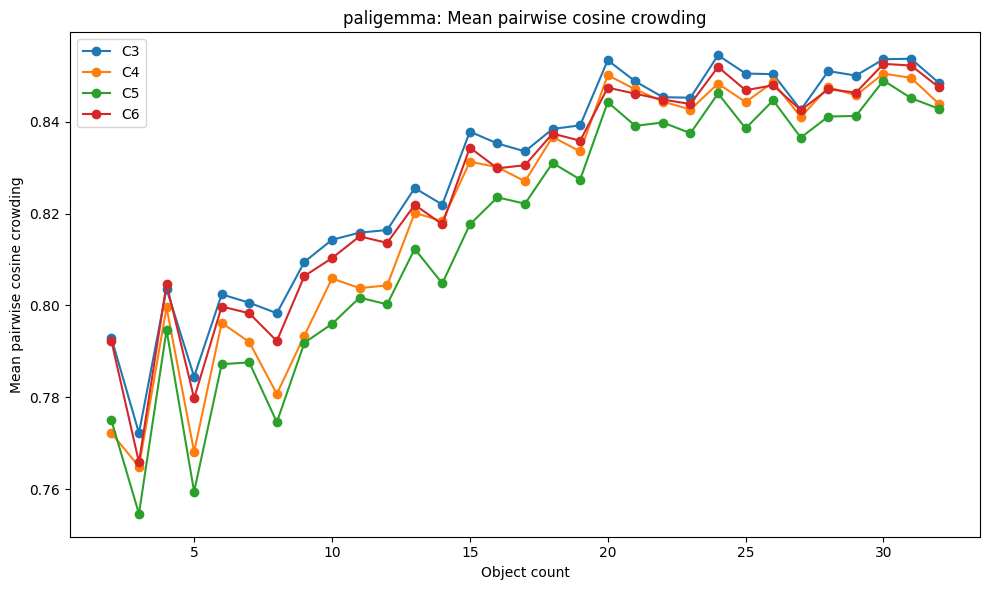

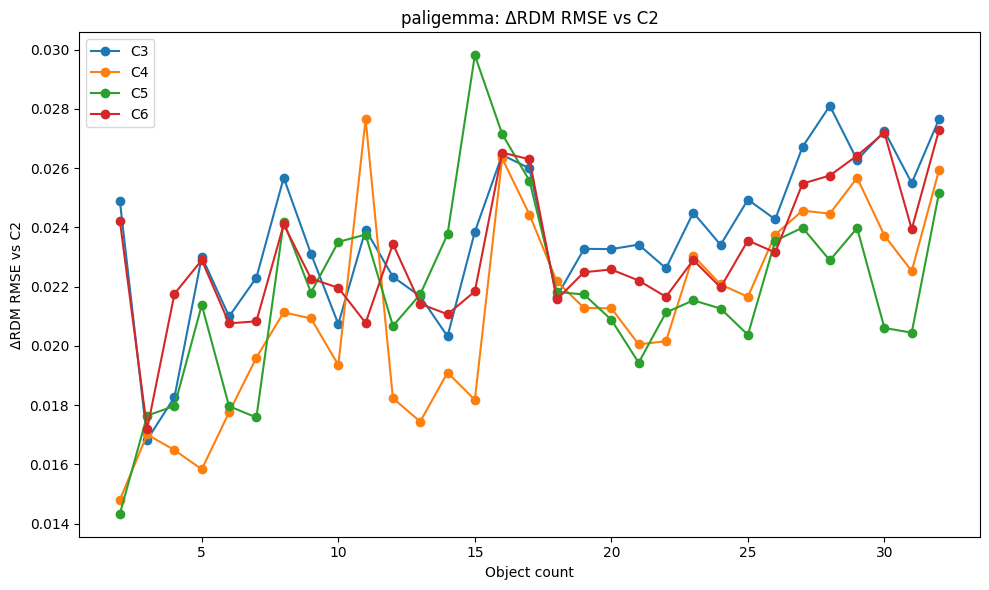

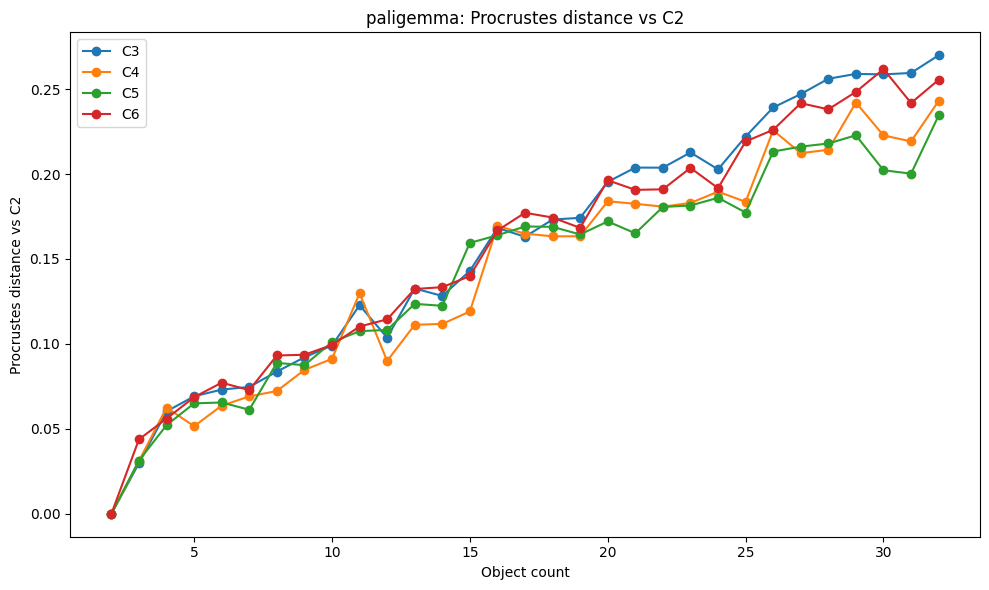

In [30]:
def plot_by_count(model_key, suffix, ylabel, filename):
    subset = geometry_results[
        (geometry_results["model"] == model_key)
        & geometry_results["is_primary_depth"]
    ]
    columns = [f"{c}_{suffix}" for c in ["c3", "c4", "c5", "c6"]]
    grouped = subset.groupby("object_count")[columns].mean()

    plt.figure(figsize=(10, 6))
    for condition in ["c3", "c4", "c5", "c6"]:
        plt.plot(
            grouped.index,
            grouped[f"{condition}_{suffix}"],
            marker="o",
            label=condition.upper(),
        )
    plt.xlabel("Object count")
    plt.ylabel(ylabel)
    plt.title(f"{model_key}: {ylabel}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / filename, dpi=180)
    plt.show()

plot_by_count(
    "paligemma", "crowding",
    "Mean pairwise cosine crowding",
    "paligemma_crowding_by_count.png",
)
plot_by_count(
    "paligemma", "rdm_rmse",
    "ΔRDM RMSE vs C2",
    "paligemma_rdm_by_count.png",
)
plot_by_count(
    "paligemma", "procrustes",
    "Procrustes distance vs C2",
    "paligemma_procrustes_by_count.png",
)

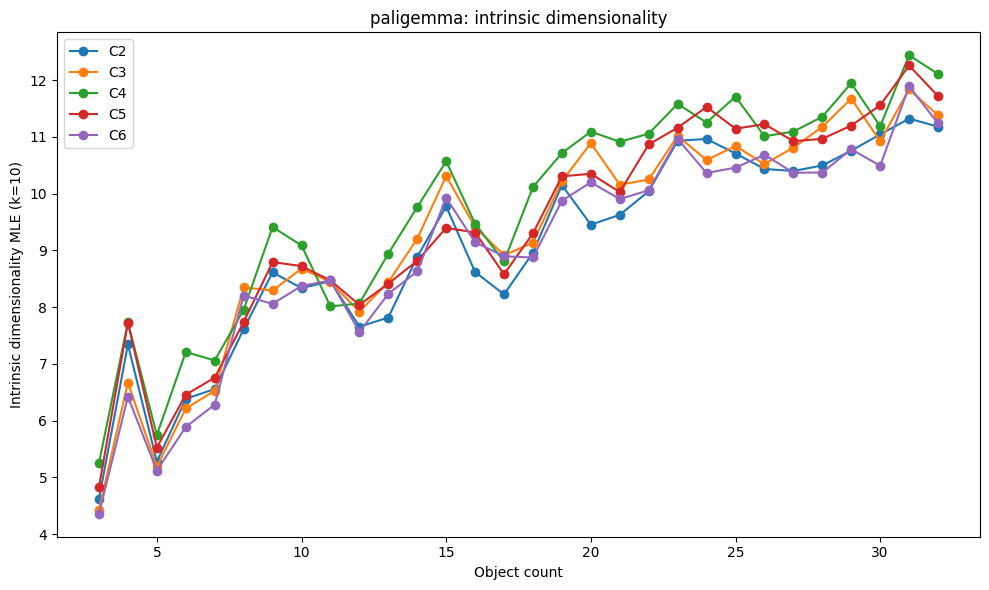

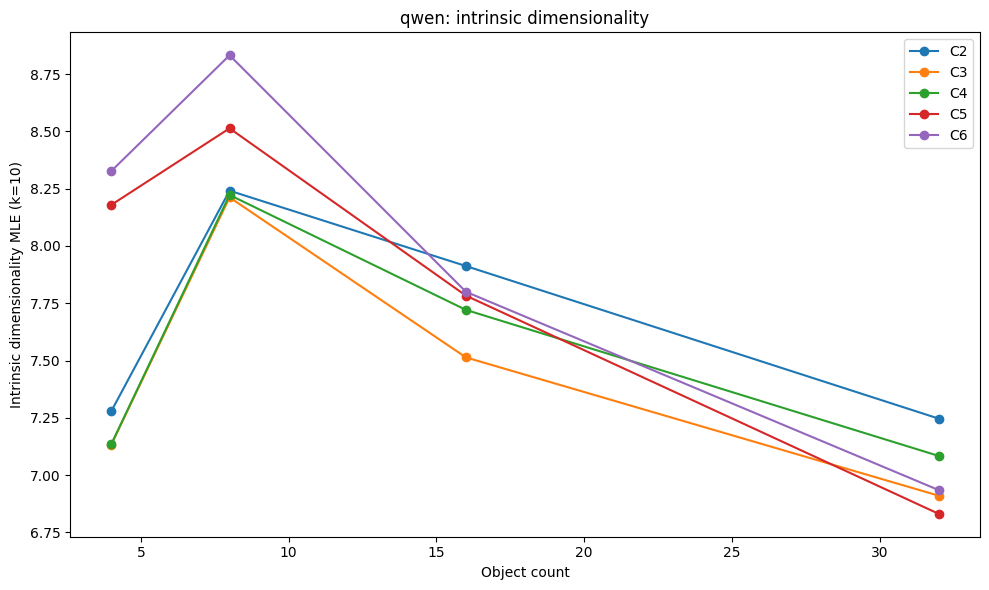

In [31]:
def plot_id(model_key):
    subset = id_results[
        (id_results["model"] == model_key)
        & (id_results["k"] == PRIMARY_ID_K)
        & id_results["is_primary_depth"]
    ]
    grouped = subset.groupby(
        ["object_count", "condition"]
    )["id_mle"].mean().unstack()

    plt.figure(figsize=(10, 6))
    for condition in CONDITIONS:
        plt.plot(
            grouped.index,
            grouped[condition],
            marker="o",
            label=condition.upper(),
        )
    plt.xlabel("Object count")
    plt.ylabel(f"Intrinsic dimensionality MLE (k={PRIMARY_ID_K})")
    plt.title(f"{model_key}: intrinsic dimensionality")
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"{model_key}_id_by_count.png", dpi=180)
    plt.show()

plot_id("paligemma")
if qwen_vectors:
    plot_id("qwen")

## 18. Final outcome and verification

In [32]:
primary_outcome = statistics_table[
    (statistics_table["contrast"] == "short_relevance_C5_minus_C4")
    & statistics_table["metric"].isin(PLANNED_METRICS)
][
    [
        "model", "metric", "unit", "n", "estimate",
        "ci_95_low", "ci_95_high", "t_p_raw",
        "holm_p_within_family", "significant_holm_0_05",
    ]
].sort_values(["model", "metric"])

def classify(model_key):
    rows = primary_outcome[primary_outcome["model"] == model_key]
    if len(rows) == 0:
        return "Not run"
    if rows["significant_holm_0_05"].any():
        return "Outcome 3A"
    return "Outcome 3B"

outcome_table = pd.DataFrame([
    {"model": m, "outcome": classify(m)}
    for m in primary_outcome["model"].unique()
])

display(primary_outcome)
display(outcome_table)

,model,metric,unit,n,estimate,ci_95_low,ci_95_high,t_p_raw,holm_p_within_family,significant_holm_0_05
42,paligemma,Intrinsic dimensionality MLE,object-count cell,30,-0.350984,-0.497459,-0.204509,3.342042e-05,0.000100,True
14,paligemma,Orthogonal Procrustes distance,image,155,-0.000704,-0.004469,0.003061,7.123753e-01,0.712375,False
7,paligemma,ΔRDM RMSE,image,155,0.000678,-0.000140,0.001496,1.037495e-01,0.207499,False
49,qwen,Intrinsic dimensionality MLE,object-count cell,4,0.285964,-0.592279,1.164206,3.762898e-01,0.376290,False
35,qwen,Orthogonal Procrustes distance,image,25,0.017415,0.012161,0.022670,4.483248e-07,0.000001,True
28,qwen,ΔRDM RMSE,image,25,0.002143,-0.000062,0.004349,5.624438e-02,0.112489,False


,model,outcome
0,paligemma,Outcome 3A
1,qwen,Outcome 3A


In [33]:
checks = []

def add_check(name, passed, detail):
    checks.append({"check": name, "passed": bool(passed), "detail": str(detail)})

add_check(
    "New dataset covers every object count 2–32",
    sorted(dataset_integrity["object_count"].unique().tolist()) == OBJECT_COUNTS,
    sorted(dataset_integrity["object_count"].unique().tolist()),
)
add_check(
    "Equal primary images per count",
    dataset_integrity.groupby("object_count")["image_id"].count().nunique() == 1,
    dataset_integrity.groupby("object_count")["image_id"].count().to_dict(),
)
add_check(
    "All PaliGemma checkpoints present",
    len(pali_vectors) == len(manifest),
    f"{len(pali_vectors)}/{len(manifest)}",
)
add_check(
    "All Qwen reduced checkpoints present",
    (not RUN_QWEN) or len(qwen_vectors) == len(qwen_records),
    f"{len(qwen_vectors)}/{len(qwen_records)}",
)
add_check(
    "Primary Holm corrections computed",
    primary_outcome["holm_p_within_family"].notna().all(),
    f"rows={len(primary_outcome)}",
)
add_check(
    "Procrustes null computed",
    len(procrustes_null) > 0,
    f"rows={len(procrustes_null)}",
)
add_check(
    "ID k robustness computed",
    set(id_results["k"].unique()) == set(ID_K_VALUES),
    sorted(id_results["k"].unique().tolist()),
)
add_check(
    "Embedding-output floor computed",
    len(layer0_floor) > 0,
    f"rows={len(layer0_floor)}",
)

verification_checklist = pd.DataFrame(checks)
verification_checklist.to_csv(
    RESULTS_DIR / "verification_checklist.csv",
    index=False,
)
display(verification_checklist)

if not verification_checklist["passed"].all():
    warnings.warn("At least one required verification check failed.")

,check,passed,detail
0,New dataset covers every object count 2–32,True,"[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 1..."
1,Equal primary images per count,True,"{2: 5, 3: 5, 4: 5, 5: 5, 6: 5, 7: 5, 8: 5, 9: ..."
2,All PaliGemma checkpoints present,True,155/155
3,All Qwen reduced checkpoints present,True,25/25
4,Primary Holm corrections computed,True,rows=6
5,Procrustes null computed,True,rows=1500
6,ID k robustness computed,True,"[5, 10, 15]"
7,Embedding-output floor computed,True,rows=720


## 19. Export complete results

In [34]:
OUTPUT_XLSX = RESULTS_DIR / "experiment3_full_fresh_results.xlsx"

with pd.ExcelWriter(OUTPUT_XLSX, engine="openpyxl") as writer:
    outcome_table.to_excel(writer, sheet_name="Outcome", index=False)
    primary_outcome.to_excel(writer, sheet_name="Primary C5-C4", index=False)
    statistics_table.to_excel(writer, sheet_name="All Statistics", index=False)
    condition_summary.to_excel(writer, sheet_name="Condition Summary", index=False)
    moderation_results.to_excel(writer, sheet_name="Count Moderation", index=False)
    id_results.to_excel(writer, sheet_name="ID All k", index=False)
    procrustes_null.to_excel(writer, sheet_name="Procrustes Null", index=False)
    layer0_floor.to_excel(writer, sheet_name="Embedding Floor", index=False)
    verification_checklist.to_excel(writer, sheet_name="Verification", index=False)

final_manifest = {
    "run_name": RUN_NAME,
    "new_data_only": True,
    "primary_model": PRIMARY_MODEL_ID,
    "secondary_model": SECONDARY_MODEL_ID,
    "primary_images": len(manifest),
    "primary_counts": OBJECT_COUNTS,
    "primary_images_per_count": N_IMAGES_PER_COUNT,
    "qwen_images": len(qwen_records),
    "qwen_counts": QWEN_COUNTS,
    "qwen_images_per_count": QWEN_IMAGES_PER_COUNT,
    "conditions": CONDITIONS,
    "all_checks_passed": bool(verification_checklist["passed"].all()),
    "outcomes": outcome_table.to_dict(orient="records"),
}

(RESULTS_DIR / "final_run_manifest.json").write_text(
    json.dumps(final_manifest, indent=2),
    encoding="utf-8",
)

print("Saved:", OUTPUT_XLSX)
print("Saved:", RESULTS_DIR / "final_run_manifest.json")

Saved: /content/drive/MyDrive/ESSR/experiment3_5images/results/experiment3_full_fresh_results.xlsx
Saved: /content/drive/MyDrive/ESSR/experiment3_5images/results/final_run_manifest.json


In [35]:
# Final checkpoint status
print(load_progress())
print("PaliGemma files:", len(list(PALIGEMMA_VECTOR_DIR.glob("*.npz"))))
print("Qwen files:", len(list(QWEN_VECTOR_DIR.glob("*.npz"))))


{}
PaliGemma files: 155
Qwen files: 25
